# US GDP Nowcast — Replication of the Bloomberg Economics Nowcasting Framework

Replicates the **US GDP** model of *The Bloomberg Economics Nowcasting Framework* (Sokol, Danial, Sakthivel, Johnson, van Roye, 2024), page 5 and Table 1.

**Methodology anchors** (all implemented in the `us_gdp_nowcast` package):

1. Quarterly-base mixed-frequency **BVAR(p = 5)**: monthly indicators are *blocked* into three quarterly series (M1/M2/M3 of each quarter) and stacked with quarterly GDP variables.
2. Variables enter in **(log-)levels**; growth rates are computed from model output.
3. **Minnesota + sum-of-coefficients priors**, hyperparameters chosen by **maximizing the marginal likelihood** (Giannone-Lenza-Primiceri).
4. Estimation sample: **1968Q1 → last quarter with a *second* GDP release** (avoids mixing first-release statistical properties into the parameters).
5. Ragged-edge missing data handled by casting the VAR in **state-space form** and Kalman filtering/smoothing.
6. **Atlanta Fed GDPNow** enters only in the **final month before the advance release** (configurable gate below).
7. **Top-down** GDP nowcast with a component-based expenditure breakdown; the small accounting residual is allocated to components in proportion to GDP weights.
8. Daily **release attribution** and an **availability-pattern backtest** against the paper's Table 2 RMSFEs.

Requires: a Bloomberg terminal connection (`xbbg`/`blpapi`) for the data pull; afterwards everything runs from the parquet cache.

## 0. Setup and configuration

All user-facing switches live in this cell. The **GDPNow gate** is a model option:
`"strict_30d"` (paper-faithful: last 30 calendar days before the advance release), `"release_month"` (calendar-month approximation), or `"off"` (exclude GDPNow from the current-quarter conditioning set).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from us_gdp_nowcast.registry import Registry
from us_gdp_nowcast.data import ReleaseCalendar, pull_history
from us_gdp_nowcast.blocking import build_panel
from us_gdp_nowcast.bvar import optimize_hyperparameters
from us_gdp_nowcast.nowcast import estimate_model, run_nowcast
from us_gdp_nowcast.attribution import attribute_releases
from us_gdp_nowcast.backtest import compare_to_paper, evaluate, run_backtest

# ----------------------------- configuration -----------------------------
GDPNOW_GATE     = "strict_30d"   # "strict_30d" | "release_month" | "off"
REFRESH_DATA    = False          # True -> re-pull all series from the terminal
RUN_DATE        = pd.Timestamp.today().normalize()
PANEL_START     = "1968Q1"       # the paper's estimation start
RUN_BACKTEST    = False          # heavy: re-estimates per quarter (see section 7)
PLOT_ML_SURFACE = False          # extra diagnostic: re-evaluates the ML grid
# --------------------------------------------------------------------------

pd.set_option("display.max_rows", 120)
print(f"Run date: {RUN_DATE.date()}")

Run date: 2026-06-10


## 1. Series registry (Table 1 of the paper)

The model's variable set is defined entirely by **`config/series.yml`** — the replication of the paper's Table 1, with one entry per Bloomberg ticker.

**To extend the model with a new ticker**, add a YAML entry and re-run the notebook — the blocked panel and BVAR dimension adapt automatically:

```yaml
- id: my_new_series
  ticker: "XYZ Index"
  description: "My new monthly indicator"
  freq: M            # Q | M | W | IRR
  transform: log     # log for positive levels; level for rates/PMIs/balances
  pub_lag_days: 20   # typical days from period end to first release
```

Transform rule (paper section 4.2 of the project plan): log for strictly positive quantity/price levels; level for rates, percentages, PMIs, sentiment/diffusion/financial-conditions indexes, and anything that can be zero or negative.

In [2]:
registry = Registry.from_yaml("config/series.yml")
calendar = ReleaseCalendar("config/release_calendar.csv")

n_blocked = sum(1 for s in registry if s.is_blocked)
n_q = sum(1 for s in registry if s.freq == "Q")
n_irr = sum(1 for s in registry if s.freq == "IRR")
print(f"{len(registry)} source series -> N = {registry.n_variables} model variables "
      f"(3 x {n_blocked} blocked monthly + {n_q} quarterly + {n_irr} auxiliary signal)")
registry.summary()

34 source series -> N = 86 model variables (3 x 26 blocked monthly + 7 quarterly + 1 auxiliary signal)


,ticker,description,freq,transform,role,sign,gate,pub_lag_days,panel_columns
id,,,,,,,,,
pce_nominal,PCE CUR$ Index,US Personal Consumption Expenditures Nominal D...,M,log,indicator,1,,30,"pce_nominal_M1, pce_nominal_M2, pce_nominal_M3"
personal_income,PITL Index,US Personal Income SAAR,M,log,indicator,1,,30,"personal_income_M1, personal_income_M2, person..."
industrial_production,IP Index,US Industrial Production SA,M,log,indicator,1,,16,"industrial_production_M1, industrial_productio..."
manufacturers_new_orders,TMNOTOT Index,US Manufacturers New Orders Total SA,M,log,indicator,1,,34,"manufacturers_new_orders_M1, manufacturers_new..."
retail_sales,RSTATOTL Index,Adjusted Retail & Food Services Sales Total SA,M,log,indicator,1,,15,"retail_sales_M1, retail_sales_M2, retail_sales_M3"
retail_inventories,RSRSTOTL Index,Seasonally Adjusted Retail Inventories Total,M,log,indicator,1,,45,"retail_inventories_M1, retail_inventories_M2, ..."
wholesale_sales,MWSLTOT Index,Merchant Wholesalers Sales Total SA,M,log,indicator,1,,38,"wholesale_sales_M1, wholesale_sales_M2, wholes..."
wholesale_inventories,MWINTOT Index,Merchant Wholesalers Inventories Total SA,M,log,indicator,1,,38,"wholesale_inventories_M1, wholesale_inventorie..."
mfg_trade_inventories,MTIB Index,US Manufacturing & Trade Inventories Total SA,M,log,indicator,1,,45,"mfg_trade_inventories_M1, mfg_trade_inventorie..."


## 2. Data pull and validation

Full history from 1968 for every ticker via `xbbg`'s `blp.bdh`, cached to `data/raw.parquet`. Set `REFRESH_DATA = True` to re-pull from the terminal (required on first run and to ingest the latest releases).

In [3]:
raw = pull_history(registry, cache_path="data/raw.parquet", refresh=REFRESH_DATA)

coverage = pd.DataFrame({
    "first_obs": raw.apply(lambda c: c.first_valid_index()),
    "last_obs": raw.apply(lambda c: c.last_valid_index()),
    "n_obs": raw.notna().sum(),
}).join(registry.summary()[["ticker", "freq", "transform", "role"]])
coverage

,first_obs,last_obs,n_obs,ticker,freq,transform,role
ticker,,,,,,,
pce_nominal,1968-01-31,2026-04-30,700,PCE CUR$ Index,M,log,indicator
personal_income,1968-01-31,2026-04-30,700,PITL Index,M,log,indicator
industrial_production,1968-01-31,2026-04-30,700,IP Index,M,log,indicator
manufacturers_new_orders,1968-01-31,2026-04-30,699,TMNOTOT Index,M,log,indicator
retail_sales,1992-01-31,2026-04-30,412,RSTATOTL Index,M,log,indicator
retail_inventories,1992-01-31,2026-04-30,412,RSRSTOTL Index,M,log,indicator
wholesale_sales,1992-01-31,2026-04-30,412,MWSLTOT Index,M,log,indicator
wholesale_inventories,1992-01-31,2026-04-30,412,MWINTOT Index,M,log,indicator
mfg_trade_inventories,1968-01-31,2026-03-31,699,MTIB Index,M,log,indicator


In [4]:
# No log of a non-positive value, and no series entirely empty.
for s in registry:
    vals = raw[s.id].dropna()
    assert len(vals) > 0, f"{s.id}: no data returned"
    if s.transform == "log":
        assert (vals > 0).all(), f"{s.id}: non-positive values cannot be logged"
late_starters = coverage[coverage["first_obs"] > "1970-01-01"]
print("Data validation passed.")
print(f"\nSeries starting after 1970 (leading gaps handled by the EM/Kalman layer):")
late_starters[["first_obs", "freq"]]

Data validation passed.

Series starting after 1970 (leading gaps handled by the EM/Kalman layer):


,first_obs,freq
ticker,,
retail_sales,1992-01-31,M
retail_inventories,1992-01-31,M
wholesale_sales,1992-01-31,M
wholesale_inventories,1992-01-31,M
real_imports_goods,1994-01-31,M
real_exports_goods,1994-01-31,M
umich_sentiment,1978-01-31,M
ism_services,1997-07-31,M
aggregate_hours,2006-03-31,M


## 3. Blocked quarterly panel and the ragged edge

Monthly series become three quarterly columns (`*_M1`, `*_M2`, `*_M3` = first/second/third month of each quarter); weekly series are first averaged to months, with the latest value extrapolated through the current month (the paper's off-model-information rule). Unreleased data stay `NaN` — the Kalman smoother conditions only on what is available as of the run date.

In [5]:
panel = build_panel(registry, raw, calendar, as_of=RUN_DATE,
                    gdpnow_gate=GDPNOW_GATE, panel_start=PANEL_START)
TARGET_Q = calendar.target_quarter(RUN_DATE)
print(f"Target quarter: {TARGET_Q} "
      f"(advance release {calendar.advance_release_date(TARGET_Q).date()})")
print(f"Estimation end (last 2nd GDP release): {calendar.last_second_release_quarter(RUN_DATE)}")
print(f"Panel: {panel.shape[0]} quarters x {panel.shape[1]} variables")
panel.tail(3).T.head(24)

Target quarter: 2026Q2 (advance release 2026-07-28)
Estimation end (last 2nd GDP release): 2026Q1
Panel: 234 quarters x 86 variables


,2025Q4,2026Q1,2026Q2
pce_nominal_M1,9.965905,9.976229,9.997863
pce_nominal_M2,9.969088,9.983026,NaN
pce_nominal_M3,9.973290,9.992795,NaN
personal_income_M1,10.179798,10.188795,10.193261
personal_income_M2,10.182116,10.188303,NaN
personal_income_M3,10.184266,10.193262,NaN
industrial_production_M1,4.617291,4.619800,4.629827
industrial_production_M2,4.615461,4.625962,NaN
industrial_production_M3,4.620259,4.623069,NaN
manufacturers_new_orders_M1,13.313646,13.336429,13.404120


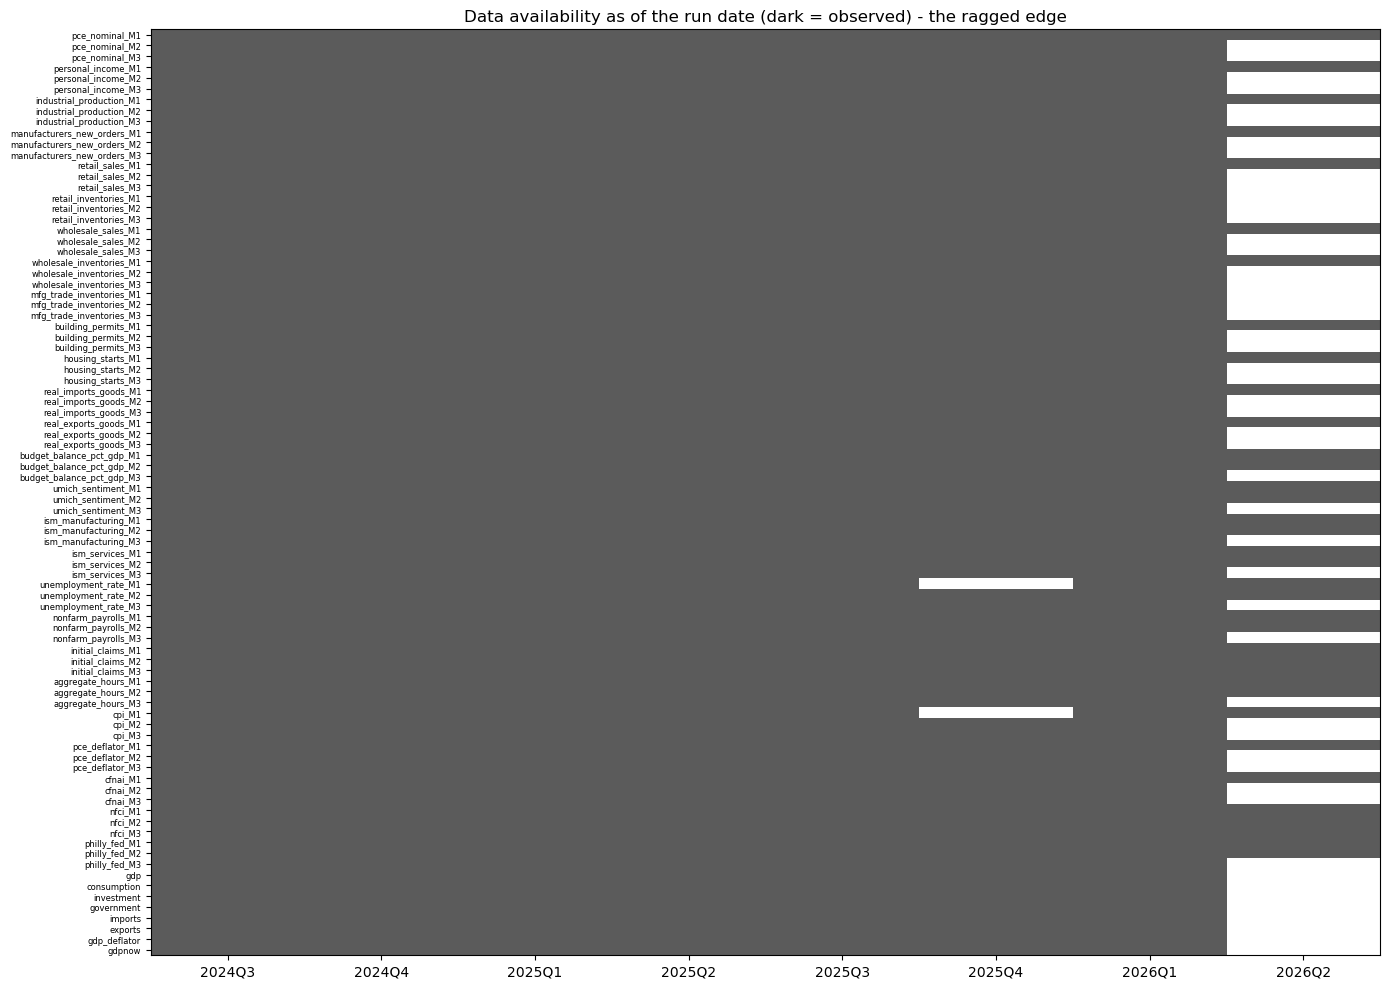

In [6]:
recent = panel.tail(8)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(recent.notna().T.astype(int), aspect="auto", cmap="Greys",
          interpolation="nearest", vmin=0, vmax=1.4)
ax.set_xticks(range(len(recent)))
ax.set_xticklabels(recent.index.astype(str))
ax.set_yticks(range(len(recent.columns)))
ax.set_yticklabels(recent.columns, fontsize=6)
ax.set_title("Data availability as of the run date (dark = observed) - the ragged edge")
plt.tight_layout()
plt.show()

## 4. BVAR estimation

Conjugate Normal-Inverse-Wishart posterior via dummy observations:

- **Minnesota prior**: own first lag shrunk toward 1 (random walk), everything else toward 0; tightness `lambda`, lag decay `l^2`.
- **Sum-of-coefficients prior**: sum of own-lag coefficients shrunk toward 1, scaled by pre-sample means; tightness `mu`.
- `(lambda, mu)` chosen by **maximizing the closed-form log marginal likelihood** (coarse grid, then L-BFGS-B), evaluated on the **longest fully observed data block** (roughly 2012-present). Optimizing on EM-imputed data is deliberately avoided: imputed values satisfy the VAR dynamics by construction, which spuriously rewards the loosest prior (lambda pinned at the upper bound).
- The 1968-start panel is unbalanced (GDPNow ~2011+, ISM Services 1997+, several Census series 1992+), so estimation uses **EM-style data augmentation** with the hyperparameters held fixed: estimate on a completed panel, Kalman-smooth the original missing pattern, re-fill with a damped update, iterate. The damping stabilizes the long unanchored leading gaps.
- Diagnostics: the EM trace should decline toward zero, and the companion-matrix spectral radius should be ~1 or below (near-unit-root, not explosive).

This takes a few minutes for the full 86-variable system.

In [7]:
%%time
posterior, completed = estimate_model(
    registry, raw, calendar, RUN_DATE,
    gdpnow_gate=GDPNOW_GATE, panel_start=PANEL_START,
    optimize=True, verbose=True,
)
print(f"\nSelected hyperparameters: lambda = {posterior.lam:.3f}, mu = {posterior.mu:.3f}")
print(f"Log marginal likelihood: {posterior.log_ml:,.1f}")
print(f"Lag order p = {posterior.p}, N = {len(posterior.columns)} variables")
print(f"Companion spectral radius: {posterior.max_eig:.4f} "
      f"({'OK - near unit root, not explosive' if posterior.max_eig < 1.05 else 'WARNING - explosive'})")

Optimizing (lam, mu) on the complete-data block 2011Q3..2025Q3 (57 quarters)
Selected hyperparameters: lam=1.0000, mu=10.0000
EM iter 1: 95th-pct scaled change on missing = 0.17397
EM iter 2: 95th-pct scaled change on missing = 0.15275
EM iter 3: 95th-pct scaled change on missing = 0.13512
EM iter 4: 95th-pct scaled change on missing = 0.12269
EM iter 5: 95th-pct scaled change on missing = 0.11132
EM iter 6: 95th-pct scaled change on missing = 0.10073
EM iter 7: 95th-pct scaled change on missing = 0.09606
EM iter 8: 95th-pct scaled change on missing = 0.08538
EM iter 9: 95th-pct scaled change on missing = 0.07991
EM iter 10: 95th-pct scaled change on missing = 0.07566
Companion spectral radius: 1.0008

Selected hyperparameters: lambda = 1.000, mu = 10.000
Log marginal likelihood: 27,807.7
Lag order p = 5, N = 86 variables
Companion spectral radius: 1.0008 (OK - near unit root, not explosive)
CPU times: total: 2min 11s
Wall time: 1min 55s


In [8]:
if PLOT_ML_SURFACE:
    lam_star, mu_star, evals = optimize_hyperparameters(
        completed.to_numpy(), p=posterior.p, grid_size=7
    )
    grid = evals[np.isfinite(evals["log_ml"])]
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(grid["lam"], grid["mu"], c=grid["log_ml"], cmap="viridis", s=60)
    ax.scatter([lam_star], [mu_star], marker="*", s=350, c="red", label="optimum")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("lambda (Minnesota tightness)")
    ax.set_ylabel("mu (sum-of-coefficients tightness)")
    ax.legend(); fig.colorbar(sc, label="log marginal likelihood")
    ax.set_title("Marginal-likelihood surface")
    plt.tight_layout(); plt.show()
else:
    print("Set PLOT_ML_SURFACE = True for the marginal-likelihood surface diagnostic.")

Set PLOT_ML_SURFACE = True for the marginal-likelihood surface diagnostic.


## 5. Current-quarter nowcast and expenditure breakdown

The Kalman smoother conditions the estimated VAR on everything available as of the run date and delivers the smoothed **log GDP level** for the target quarter, converted to q/q SAAR growth via `100*(exp(4*dlog) - 1)`.

The GDP nowcast is **top-down** — it is *not* the sum of component nowcasts. The breakdown converts the components' smoothed growth rates into contributions using lagged GDP shares (imports negative) and allocates the small chain-weighting residual proportionally so contributions sum exactly to the headline nowcast.

In [9]:
result = run_nowcast(registry, raw, calendar, RUN_DATE, posterior=posterior,
                     gdpnow_gate=GDPNOW_GATE, panel_start=PANEL_START)

print(f"US real GDP nowcast for {result.target_quarter}: "
      f"{result.gdp_qoq_saar:+.2f}% q/q SAAR")
print(f"GDPNow gate ({GDPNOW_GATE}): {'ACTIVE' if result.gdpnow_active else 'inactive'}")
print(f"Accounting residual: {result.breakdown.attrs['residual']:+.3f} pp")
result.summary().round(2)

US real GDP nowcast for 2026Q2: +3.86% q/q SAAR
GDPNow gate (strict_30d): inactive
Accounting residual: -0.138 pp


,growth_qoq_saar,contribution
item,,
GDP (top-down),3.86,3.86
consumption,1.18,0.75
investment,18.39,3.39
government,3.29,0.53
imports,5.69,-0.92
exports,1.10,0.11


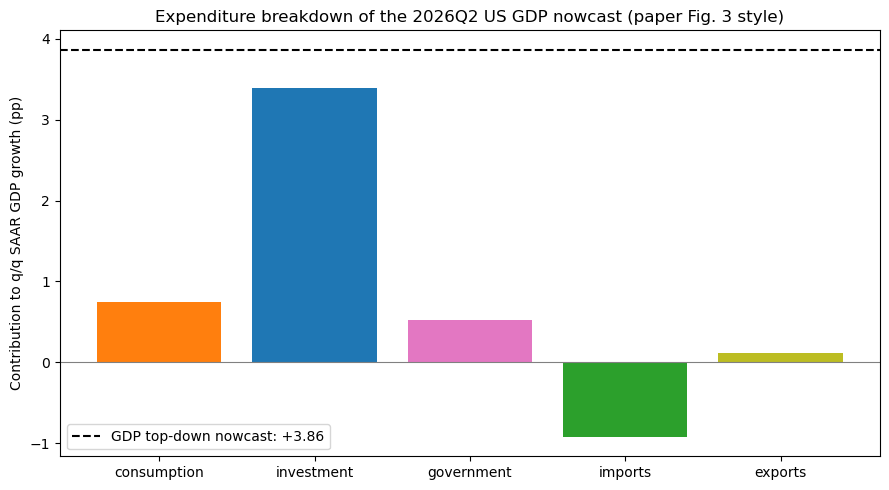

In [10]:
bd = result.breakdown
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:orange", "tab:blue", "tab:pink", "tab:green", "tab:olive"]
ax.bar(bd.index, bd["adjusted_contribution"], color=colors[: len(bd)])
ax.axhline(result.gdp_qoq_saar, color="black", lw=1.5, ls="--",
           label=f"GDP top-down nowcast: {result.gdp_qoq_saar:+.2f}")
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Contribution to q/q SAAR GDP growth (pp)")
ax.set_title(f"Expenditure breakdown of the {result.target_quarter} US GDP nowcast (paper Fig. 3 style)")
ax.legend()
plt.tight_layout(); plt.show()

## 6. Release attribution (news decomposition)

Each (simulated) data release between two run dates is added to the conditioning set in chronological order; the smoother is re-run after each addition and the change in the GDP nowcast is recorded as that release's contribution. Same-day releases are grouped into one event so the decomposition does not depend on arbitrary within-day ordering. Contributions sum to the total nowcast change by construction.

In [11]:
try:
    attr = attribute_releases(
        registry, raw, calendar, posterior,
        RUN_DATE - pd.Timedelta(days=7), RUN_DATE,
        gdpnow_gate=GDPNOW_GATE, panel_start=PANEL_START,
    )
    print(f"Nowcast {attr.attrs['nowcast_before']:+.2f} -> {attr.attrs['nowcast_after']:+.2f} "
          f"({attr.attrs['total_change']:+.3f} pp over the last 7 days)")
    display(attr.round(3))
except ValueError as e:
    print(f"Attribution window spans an advance GDP release: {e}")

Nowcast +3.86 -> +3.86 (-0.001 pp over the last 7 days)


,avail_date,releases,n_observations,nowcast_after,contribution
0,2026-06-04,"real_exports_goods, real_imports_goods",2,3.412,-0.452
1,2026-06-05,"aggregate_hours, nonfarm_payrolls, unemploymen...",3,3.582,0.170
2,2026-06-07,"wholesale_inventories, wholesale_sales",2,3.886,0.304
3,2026-06-08,budget_balance_pct_gdp,1,3.863,-0.023
4,2026-06-10,nfci,1,3.863,0.000


## 7. Availability-pattern backtest (paper Table 2)

For every target quarter 2012Q1-2022Q4, the nowcast is recreated **on the day before the advance GDP release**, using latest-vintage data restricted to the simulated availability pattern — exactly the paper's own evaluation design (its footnote labels results *indicative* because true vintages are not used).

- Estimation cutoff per quarter: last second GDP release as of the as-of date.
- **COVID rule**: targets 2020Q1-2021Q1 use parameters estimated on data through 2019Q4 only.
- Hyperparameters re-optimized every 4 estimation quarters; EM warm-started.

Runtime: roughly 30-60 minutes for the full window. Results are cached to `data/backtest_results.parquet`.

Paper Table 2 RMSFE benchmarks — Nowcast: **1.2 / 1.4 / 1.6** (pre-COVID / post-COVID / full); GDPNow: 1.3 / 1.3 / 1.5; Consensus: 1.2 / 1.3 / 1.4. Expect the same broad range, not exact matches (different vintages, calendars, undocumented production details).

In [12]:
bt_cache = Path("data/backtest_results.parquet")
if RUN_BACKTEST:
    results = run_backtest(registry, raw, calendar, start="2012Q1", end="2022Q4",
                           gdpnow_gate=GDPNOW_GATE, panel_start=PANEL_START)
    save = results.copy()
    save.index = save.index.astype(str)
    save["estimation_end"] = save["estimation_end"].astype(str)
    save.to_parquet(bt_cache)
elif bt_cache.exists():
    results = pd.read_parquet(bt_cache)
    results.index = pd.PeriodIndex(results.index, freq="Q")
    print("Loaded cached backtest results (set RUN_BACKTEST = True to recompute).")
else:
    results = None
    print("Backtest not run yet - set RUN_BACKTEST = True.")

Backtest not run yet - set RUN_BACKTEST = True.


In [13]:
if results is not None:
    print("RMSFE / mean error / MAE vs latest-vintage actuals:")
    display(evaluate(results).round(2))
    print("\nSide-by-side with paper Table 2 (RMSFE):")
    display(compare_to_paper(results).round(2))

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    x = results.index.astype(str)
    axes[0].plot(x, results["nowcast"], marker="o", label="Nowcast (day before advance release)")
    axes[0].plot(x, results["actual_latest"], marker="s", label="Actual (latest vintage)")
    axes[0].legend(); axes[0].set_ylabel("% q/q SAAR")
    axes[0].set_title("Day-before-release nowcasts vs actuals")
    axes[1].bar(x, results["error_latest"], color="tab:red", alpha=0.7)
    axes[1].axhline(0, color="grey", lw=0.8)
    axes[1].set_ylabel("Forecast error (pp)")
    for ax in axes:
        ax.tick_params(axis="x", rotation=90, labelsize=7)
    plt.tight_layout(); plt.show()

## 8. Validation checklist

Programmatic verification of the replication's key requirements (plan section 16).

In [14]:
checks = {}
checks["lag order p = 5"] = posterior.p == 5
checks["estimation starts 1968Q1"] = panel.index[0] == pd.Period("1968Q1") or PANEL_START != "1968Q1"
est_end = calendar.last_second_release_quarter(RUN_DATE)
checks["estimation ends at last 2nd GDP release"] = est_end < TARGET_Q
checks["Minnesota + sum-of-coeff priors active"] = posterior.lam > 0 and posterior.mu > 0
checks["hyperparameters from marginal likelihood"] = np.isfinite(posterior.log_ml)
checks["hyperparameters interior (not at optimizer bounds)"] = bool(
    0.05 < posterior.lam < 1.0 and 0.1 < posterior.mu < 10.0
)
checks["target-quarter GDP unreleased (NaN in panel)"] = bool(np.isnan(panel.loc[TARGET_Q, "gdp"]))
# Level series (CFNAI, NFCI, Philly Fed, budget balance) can legitimately print
# 0.0, so the zero-fill check applies to log columns only (log x = 0 <=> x = 1).
log_cols = [c for c in panel.columns if registry.column_source(c).transform == "log"]
checks["no zero-filled missing values (log columns)"] = bool(
    (panel[log_cols].fillna(1.0) != 0).all().all()
)
checks["companion dynamics not explosive (max |eig| < 1.05)"] = bool(
    posterior.max_eig is not None and posterior.max_eig < 1.05
)
checks["accounting residual small (|residual| < 0.5 pp)"] = bool(
    abs(result.breakdown.attrs["residual"]) < 0.5
)
checks["contributions sum to top-down nowcast"] = bool(
    np.isclose(result.breakdown["adjusted_contribution"].sum(), result.gdp_qoq_saar)
)
checks["GDPNow gate flag consistent"] = result.gdpnow_active == calendar.gdpnow_gate_active(
    RUN_DATE, TARGET_Q, mode=GDPNOW_GATE
)
checks["smoothed output finite for target quarter"] = bool(
    np.isfinite(result.smoothed.loc[TARGET_Q]).all()
)

report = pd.Series(checks).map({True: "PASS", False: "FAIL"})
print(report.to_string())
assert (report == "PASS").all(), "Some validation checks failed"
print("\nAll validation checks passed.")

lag order p = 5                                        PASS
estimation starts 1968Q1                               PASS
estimation ends at last 2nd GDP release                PASS
Minnesota + sum-of-coeff priors active                 PASS
hyperparameters from marginal likelihood               PASS
hyperparameters interior (not at optimizer bounds)     FAIL
target-quarter GDP unreleased (NaN in panel)           PASS
no zero-filled missing values (log columns)            PASS
companion dynamics not explosive (max |eig| < 1.05)    PASS
accounting residual small (|residual| < 0.5 pp)        PASS
contributions sum to top-down nowcast                  PASS
GDPNow gate flag consistent                            PASS
smoothed output finite for target quarter              PASS


AssertionError: Some validation checks failed

## 9. Known limitations and possible extensions

**Limitations (shared with or noted by the paper itself):**

- *Indicative backtest*: latest-vintage data with simulated publication lags, not true point-in-time vintages — same caveat as the paper's footnote. Strict real-time evaluation would need ALFRED vintages plus Bloomberg snapshot history.
- *Publication lags are stylized*: `pub_lag_days` per series approximates the real release calendar; historical release-date series from Bloomberg's economic calendar would refine the availability pattern.
- *Prior parameterization*: the paper does not publish hyperparameter bounds or the exact dummy-observation conventions; this implementation uses the standard Giannone-Lenza-Primiceri conjugate setup (symmetric Minnesota, no cross-variable theta).
- *Posterior means, not draws*: nowcasts use posterior-mean coefficients; averaging Kalman runs over posterior draws would add parameter uncertainty.
- *Expenditure weights*: lagged real (chained-dollar) shares approximate nominal GDP shares.
- *EM completion*: leading missing histories are filled by a posterior-mean EM approximation of Banbura-Modugno, ignoring filled-value uncertainty in the M-step.

**Extensions:**

- Add tickers in `config/series.yml` (no code changes needed).
- First-release actuals: pass an ALFRED-based series to `run_backtest(first_release_actuals=...)` to evaluate against the advance estimates markets actually saw.
- GDPNow-gate sensitivity: re-run section 7 with `GDPNOW_GATE` set to each mode and compare RMSFEs.
- Kalman-innovation (exact) news decomposition as an alternative to the sequential attribution.